# 迁移学习  
迁移学习( Transfer Learning )是一种利用从一项任务中获得的知识来解决另一项类似任务的技术。一个使用数百万张图像训练的模型，训练数据涵盖数千种对象类别，模型的卷积核将能够学习图像中的各种形状、颜色和纹理，通过重用这些卷积核可以学习到新图像的特征，并最终用于执行计算机视觉任务。随着训练数据集中可用图像数量的增加，模型的分类准确率会不断提高，然而，在实际训练模型过程中，获取大量具有标签的数据样本通常比较困难，需要耗费大量时间和人力成本，而迁移学习能够在训练数据不足的情况下实现更好的泛化性能。

## 1. 迁移学习
### 1.1 迁移学习基本概念  
迁移学习指利用已经学习好的模型在新任务上具有良好的表现和推广能力的机器学习技术，能够将通用数据集上的模型学习迁移到特定数据集中。通常，用于执行迁移学习的预训练模型在数百万张图像(通用大型数据集)上进行训练，然后使用特定感兴趣数据集微调预训练模型。

![14.1](../Images/14.1.png)

### 1.2 迁移学习的重要性

假设我们需要处理道路图像，并根据图像包含的对象进行分类，而从零开始构建、训练模型可能会因为图像的数量不足，而难以学习到数据集中的各种变化，正如在猫狗分类模型中所看到的，对 8,000 张图像进行训练比在 2000 张图像上进行训练的模型准确率更高。在 ImageNet 上训练的预训练模型能够很好的解决该问题，在对 ImageNet 数据集进行训练期间，模型已经学习了很多与交通相关的特征，例如汽车、道路、树木和人等。因为模型已经学习了大量通用特征，因此，利用已经训练好的模型能够更快和更准确的训练新模型，只需要将预训练模型提取到的特征用于新模型的训练，就可以得到适用于目标任务的性能优异的新模型。

### 1.3 ImageNet  
ImageNet 是一个大规模图像数据集，该数据集包含了超过 1400 万张标注图像，覆盖了 1 万多个分类标签。ImageNet 数据集被广泛用于计算机视觉领域中，包括自动驾驶、智能监控、医学影像分析等。ImageNet 挑战赛由 ImageNet 项目组于 2010 年开始举办，是计算机视觉领域的顶尖比赛之一。在本节中，将使用在 ImageNet 数据集上预训练的深度神经网络构建迁移学习模型。


### 1.4 迁移学习流程  
迁移学习的一般流程如下：
- 归一化输入图像，使用与预训练模型训练期间相同的均值和标准差进行归一化
- 获取在大型数据集上进行预训练模型的架构与模型权重
- 丢弃预训练模型的最后几层
- 将截断的预训练模型连接到一个或多个新初始化的神经网络层，并确保最后一层的神经元与需要预测的类别数(输出)相同
- 确保预训练模型的权重不可更新(即在反向传播期间冻结预训练模型参数)，但新初始化的神经网络层权重是可训练的。因为预训练模型权重已经使用大型数据集进行了很好的训练，因此可以利用从大型模型中学习到的特征而无需对预训练模型进行训练，而只需要利用小数据集训练新初始化的神经网络层
- 更新可训练参数，拟合模型  
我们已经了解了如何实现迁移学习，接下来，我们介绍预训练卷积神经网络架构 VGG，并使用迁移学习将预训练模型应用于猫狗分类任务。

## 2.VG16架构 
Visual Geometry Group (VGG) 是由牛津大学的研究人员在 2014 年提出的卷积神经网络架构，其中 16 代表模型中的层数，包含 13 层的卷积层，3 层的全连接层。 VGG16 分类模型在 2014 年的 ImageNet 比赛中获得了亚军，是一种广泛应用于计算机视觉任务的模型架构。VGG16 中的卷积层使用小尺寸的卷积核，以增加网络深度，提高模型的非线性能力，并且能够提取更丰富的特征。接下来，我们介绍 VGG16 架构以及如何在 PyTorch 中使用 VGG16 预训练模型。


1. 导入所需要的库

In [1]:
import torch
from torchvision import transforms,models,datasets
from torchsummary import summary
device = "cpu"

>torchvision 包中的 models 模块提供了 PyTorch 中可用的预训练模型。

2. 加载 VGG16 模型并在设备内注册模型：

In [9]:
model = models.vgg16(pretrained=True).to(device)

e:\Users\Admin\anaconda3\envs\new_pytorch\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\Users\Admin\anaconda3\envs\new_pytorch\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


在以上代码中，models 类中调用了 vgg16 方法，通过使用 pretrained = True 指定加载用于在 ImageNet 竞赛中对图像进行分类的权重，然后将模型注册到设备中。

3. 打印模型摘要

In [10]:
summary(model, (3, 224, 224), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

神经网络各层可视化如下：  
![14.2](../Images/14.2.png)

该网络中约有 1.38 亿个参数(网络末端的线性层包括约 102 万 + 16 万 + 400 万 = 1.22 亿个参数)，其中包括 13 个卷积层和 3 个线性层，可以使用 models 打印 VGG16 模型组件：

In [11]:
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

模型中包括三个主要的子模块——features、avgpool 和 classifier，通常，需要冻结 features 和 avgpool 模块，删除分类器 (classifier) 模块并在其位置创建一个新的 classifier 模块，用于预测新任务所需的图像类别。

1. 使用预训练 VGG16 模型实现猫狗分类

接下来，我们介绍如何在实践中使用 VGG16 模型，仅使用 1000 张图像(猫、狗图像各 500 张)构建猫狗分类模型。

In [44]:
import torch.nn as nn
import torch
from torchvision import transforms, models
import matplotlib.pyplot as plt
import numpy as np
device = 'cpu'
import cv2, glob
from glob import glob
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset


2. 下载猫狗分类数据集、解压并指定训练和测试目录：

In [45]:
train_data_dir = r'E:\pwr\leaning\Start-with-Pytorch\data\cat&dog\training_set\training_set'
test_data_dir  = r'E:\pwr\leaning\Start-with-Pytorch\data\cat&dog\test_set\test_set'

3. 定义 Dataset 类，用于返回猫狗数据集的输入-输出对，使用 transforms 模块中的 Normalize 调用 normalize 函数执行数据归一化，并获取每个文件夹中的前 500 张图像：

In [46]:
class CatsDogs(Dataset):
    def __init__(self, folder):
        dogs = glob(folder+'/dogs/*.jpg')
        cats = glob(folder+'/cats/*.jpg')
        self.fpaths = cats[:500] + dogs[:500]
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
        from random import shuffle, seed; seed(10); shuffle(self.fpaths)
        self.targets = [fpath.split('/')[-1].startswith('dog') for fpath in self.fpaths]
    def __len__(self):
        return len(self.fpaths)
    def __getitem__(self, ix):
        f = self.fpaths[ix]
        target = self.targets[ix]
        im = (cv2.imread(f)[:,:,::-1])
        im = cv2.resize(im, (224,224))
        im = torch.tensor(im/255)
        im = im.permute(2,0,1)
        im = self.normalize(im)
        return im.float().to(device), torch.tensor([target]).float().to(device)

在利用预训练模型时，必须对图像调整大小、交换通道顺序和归一化(根据所用预训练模型)，图像将 3 个通道上的像素值缩放至 0 到 1 之间，然后使用指定平均值( [0.485, 0.456, 0.406] )和标准差( [0.229, 0.224, 0.225] )归一化 RGB 通道。

4. 获取图像及其标签，抽样检查示例图像及其对应的类别标签： 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.64].


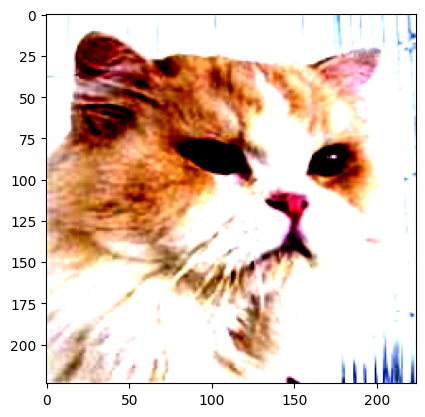

tensor([0.])


In [47]:
data = CatsDogs(train_data_dir)

im, label = data[100]
plt.imshow(im.permute(1,2,0).cpu())
plt.show()
print(label)

5. 定义模型，下载预训练的 VGG16 权重，冻结特征提取模块，并训练新的分类器。

- 首先，利用 models 类下载预训练的 VGG16 模型：

In [48]:
def get_model():
    model = models.vgg16(pretrained=True)

- 通过指定 param.requires_grad = False 在反向传播期间冻结模型参数： 

In [49]:
for param in model.parameters():
    param.requires_grad = False

- 替换 avgpool 模块以返回大小为 1 x 1 的特征图替换原模型中 7 x 7 的特征图，即输出尺寸变为 batch_size x 512 x 1 x 1：

In [50]:
model.avgpool = nn.AdaptiveAvgPool2d(output_size=(1, 1))

>在 PyTorch 中，nn.MaxPool2d 用于从特征图的每个部分中选择最大值，而 nn.AvgPool2d 会返回特征图每个部分的平均值，在这两个网络层中使用了固定大小的核。nn.AdaptiveAvgPool2d 是另一类池化层，可以指定输出特征图的尺寸，该层自动计算核大小，以便返回指定尺寸的特征图。例如，如果输入特征图尺寸为 batch_size x 512 x k x k，想要得到尺寸为的特征图 batch_size x 512 x 21 x 1，则池化核大小为 k x k，而使用 nn.AdaptiveAvgPool2d 层无论输入尺寸如何，其输出尺寸始终是固定的，因此，神经网络可以接受任何尺寸的输入图像。

定义模型的分类器模块，首先展平 avgpool 模块的输出，然后连接到具有 128 个单元的隐藏层，并在执行激活函数后连接到输出层：

In [51]:
model.classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(512,128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128,1),
    nn.Sigmoid()
)

- 定义损失函数 (loss_fn)、优化器：

In [55]:
def get_model():
    model = models.vgg16(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False
    model.avgpool = nn.AdaptiveAvgPool2d(output_size=(1, 1))
    model.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(512,128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128,1),
        nn.Sigmoid()
    )
    #定义损失函数 (loss_fn)、优化器：
    loss_fn = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr= 1e-3)
    return model.to(device), loss_fn, optimizer

- 在以上代码中，我们首先冻结了预训练模型的所有参数，然后定义了新的 avgpool 和分类器模块，打印模型摘要：

In [58]:
from torchsummary import summary
model, criterion, optimizer = get_model()
summary(model, (3, 224, 224), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

>输出中省去了与预训练模型中相同的网络层，模型共有 1470 万个参数，其中可训练参数的数量只有 65,793 个，因为模型中只有分类器模块具有要学习的权重。

6. 定义函数获取数据、训练模型、计算准确度：

In [60]:
def train_batch(x, y, model, optimizer, loss_fn):
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()

def accuracy(x, y, model):
    with torch.no_grad():
        prediction = model(x)
    is_correct = (prediction > 0.5) == y
    return is_correct.cpu().numpy().tolist()

def get_data():
    train = CatsDogs(train_data_dir)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True, drop_last = True)
    val = CatsDogs(test_data_dir)
    val_dl = DataLoader(val, batch_size=32, shuffle=True, drop_last = True)
    return trn_dl, val_dl

@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    prediction = model(x)
    val_loss = loss_fn(prediction, y)
    return val_loss.item()

7. 初始化 get_data() 和 get_model() 函数：

In [62]:
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

8. 训练模型，并绘制模型训练过程中训练和测试准确率：

 epoch 1/10
 epoch 2/10
 epoch 3/10
 epoch 4/10
 epoch 5/10
 epoch 6/10
 epoch 7/10
 epoch 8/10
 epoch 9/10
 epoch 10/10


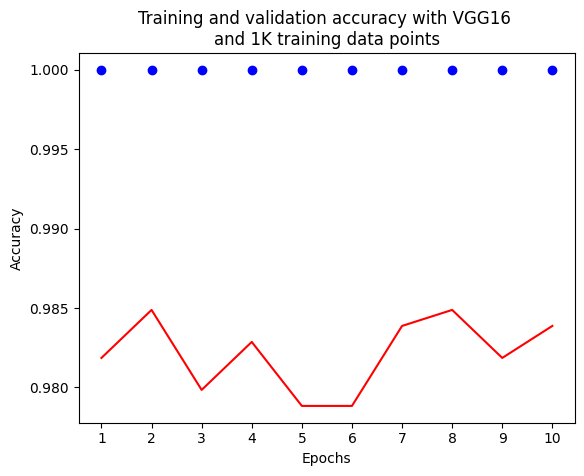

In [64]:
train_losses, train_accuracies = [], []
val_accuracies = []
for epoch in range(10):
    print(f" epoch {epoch + 1}/10")
    train_epoch_losses, train_epoch_accuracies = [], []
    val_epoch_accuracies = []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss) 
    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        val_epoch_accuracies.extend(val_is_correct)
    val_epoch_accuracy = np.mean(val_epoch_accuracies)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_accuracies.append(val_epoch_accuracy)

epochs = np.arange(10)+1
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with VGG16 \nand 1K training data points')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

可以看到，在第一个 epoch 结束时模型准确率就可以达到 98%，即使训练数据集中仅包含 1,000 张图像(每个类别 500 张图像)。​
除了 VGG16，也可以使用 VGG11 和 VGG19 预训练神经网络架构，它们的工作方式与 VGG16 类似，仅层数不同。 VGG19 比 VGG16 有更多的参数，因为它有更多的网络层。​
使用 VGG11 和 VGG19 代替 VGG16 预训练模型时的训练和验证准确率如下：  
![14.3](../Images/14.3.png)

可以看到，基于 VGG19 模型的准确率略高于基于 VGG16 的模型，在验证数据上的准确率为 98%，基于 VGG11 模型的准确率略低，为 97%。

## 小结  
迁移学习通过利用相关任务或领域的知识，帮助解决新任务或领域中的学习挑战，可以提高模型的泛化能力、加速模型训练，并在实际应用中取得良好的效果。在图像分类、目标检测、机器翻译等任务中，迁移学习已经展现出巨大的应用价值。在本节中，介绍了迁移学习的基本概念，并使用 PyTorch 构建了迁移学习模型，利用预训练模型 VGG 加速学习过程并提高性能。